# 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType

RANDOM_SEED = 42
SAMPLE_FRAC = 0.01

pd.set_option("display.max_columns", None)

/Users/elifsen/Projects/nyc_taxi/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
spark = SparkSession.builder.appName("nyc_taxi").getOrCreate()

26/05/11 11:15:02 WARN Utils: Your hostname, elif-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 10.0.0.194 instead (on interface en7)
26/05/11 11:15:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/11 11:15:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# 2. Data Loading

In [3]:
path = kagglehub.dataset_download("anandaramg/taxi-trip-data-nyc")

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith(".csv"):
            csv_path = os.path.join(dirname, filename)

data = spark.read.csv(csv_path, header=True, inferSchema=True)

# 3. Initial Exploration

In [4]:
data.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- lpep_pickup_datetime: timestamp (nullable = true)
 |-- lpep_dropoff_datetime: timestamp (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- ehail_fee: string (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- trip_type: integer (nullable = true)
 |-- congestion_surcharge: double (nullable = true)



# 4. Data Quality Checks

In [5]:
df = data.sample(fraction=0.01)
df.describe().show()

26/05/11 11:15:06 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+---------+---------------------+-----------------+------------------+-------------------+--------------------+
|summary|           VendorID|store_and_fwd_flag|        RatecodeID|      PULocationID|      DOLocationID|   passenger_count|     trip_distance|       fare_amount|             extra|           mta_tax|        tip_amount|      tolls_amount|ehail_fee|improvement_surcharge|     total_amount|      payment_type|          trip_type|congestion_surcharge|
+-------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+---------+---------------------+-----------------+--------------

In [6]:
# double typelar floata çevrildi

df = (df.withColumn("trip_distance", col("trip_distance").cast("float"))
        .withColumn("fare_amount", col("fare_amount").cast("float"))
        .withColumn("extra", col("extra").cast("float"))
        .withColumn("mta_tax", col("mta_tax").cast("float"))
        .withColumn("tip_amount", col("tip_amount").cast("float"))
        .withColumn("tolls_amount", col("tolls_amount").cast("float"))
        .withColumn("total_amount", col("total_amount").cast("float"))
        .withColumn("congestion_surcharge", col("congestion_surcharge").cast("float"))
        )

df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- lpep_pickup_datetime: timestamp (nullable = true)
 |-- lpep_dropoff_datetime: timestamp (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: float (nullable = true)
 |-- fare_amount: float (nullable = true)
 |-- extra: float (nullable = true)
 |-- mta_tax: float (nullable = true)
 |-- tip_amount: float (nullable = true)
 |-- tolls_amount: float (nullable = true)
 |-- ehail_fee: string (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: float (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- trip_type: integer (nullable = true)
 |-- congestion_surcharge: float (nullable = true)



In [7]:
print(f"satır sayısı: {df.count()}")
print(f"sütun sayısı: {len(df.columns)}")
df.summary().show()

satır sayısı: 845
sütun sayısı: 20
+-------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+---------+---------------------+------------------+------------------+-------------------+--------------------+
|summary|           VendorID|store_and_fwd_flag|        RatecodeID|      PULocationID|      DOLocationID|   passenger_count|     trip_distance|       fare_amount|             extra|           mta_tax|        tip_amount|     tolls_amount|ehail_fee|improvement_surcharge|      total_amount|      payment_type|          trip_type|congestion_surcharge|
+-------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+---------+--------------------

In [8]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()
def missing_report_pyspark(df):
    null_counts = df.select([
        F.mean(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]).collect()[0].asDict()
    
    report_df = spark.createDataFrame(
    [(k, v) for k, v in null_counts.items()], 
            ["column_name", "missing_ratio"]
        )
    report_df = report_df.withColumn("missing_ratio", col("missing_ratio").cast("float"))
    
    return report_df.withColumn("missing_ratio", F.round("missing_ratio", 4)).orderBy(F.desc("missing_ratio"))
missing_report = missing_report_pyspark(df)
missing_report.show()

+--------+--------------------+---------------------+------------------+----------+------------+------------+---------------+-------------+-----------+-----+-------+----------+------------+---------+---------------------+------------+------------+---------+--------------------+
|VendorID|lpep_pickup_datetime|lpep_dropoff_datetime|store_and_fwd_flag|RatecodeID|PULocationID|DOLocationID|passenger_count|trip_distance|fare_amount|extra|mta_tax|tip_amount|tolls_amount|ehail_fee|improvement_surcharge|total_amount|payment_type|trip_type|congestion_surcharge|
+--------+--------------------+---------------------+------------------+----------+------------+------------+---------------+-------------+-----------+-----+-------+----------+------------+---------+---------------------+------------+------------+---------+--------------------+
|     322|                   0|                    0|               322|       322|           0|           0|            322|            0|          0|    0|      

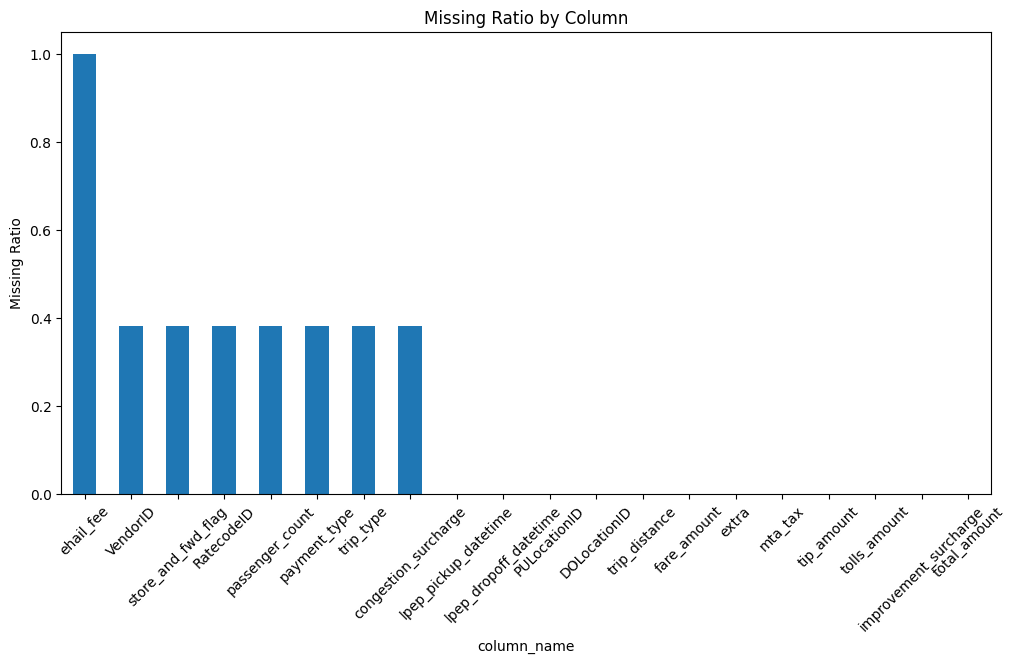

In [9]:
pd_report = missing_report.toPandas()
pd_report.set_index("column_name", inplace=True)
pd_report["missing_ratio"].plot(kind="bar", title="Missing Ratio by Column", figsize=(12, 6))
plt.ylabel("Missing Ratio")
plt.xticks(rotation=45)
plt.show()

# 5. Data Cleaning

In [10]:
df.show()

+--------+--------------------+---------------------+------------------+----------+------------+------------+---------------+-------------+-----------+-----+-------+----------+------------+---------+---------------------+------------+------------+---------+--------------------+
|VendorID|lpep_pickup_datetime|lpep_dropoff_datetime|store_and_fwd_flag|RatecodeID|PULocationID|DOLocationID|passenger_count|trip_distance|fare_amount|extra|mta_tax|tip_amount|tolls_amount|ehail_fee|improvement_surcharge|total_amount|payment_type|trip_type|congestion_surcharge|
+--------+--------------------+---------------------+------------------+----------+------------+------------+---------------+-------------+-----------+-----+-------+----------+------------+---------+---------------------+------------+------------+---------+--------------------+
|       2| 2021-07-01 07:02:04|  2021-07-01 07:14:42|                 N|         1|         132|          86|              1|          5.7|       17.5|  0.0|    0.

In [11]:
def remove_high_missing_columns(df, threshold=0.5):
    missing_report = missing_report_pyspark(df)
    columns_to_drop = missing_report.filter(col("missing_ratio") > threshold).select("column_name").rdd.flatMap(lambda x: x).collect()
    return df.drop(*columns_to_drop)

def remove_negative_values(df):
    numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]

    for column in numeric_cols:
        df = df.filter(F.col(column) >= 0)

    return df

def filter_business_rules(df):
    year_condition = (
            ((F.year("lpep_pickup_datetime") >= 2015) & (F.col("improvement_surcharge") == 0.3)) |
            ((F.year("lpep_pickup_datetime") < 2015) & (F.col("improvement_surcharge") == 0.0))
        )
        
    business_conditions = (
            (F.col("total_amount") > 5) &
            (F.col("trip_distance") > 0) &
            (F.col("passenger_count") > 0) &
            (~F.col("RatecodeID").isin(3, 4)) &
            (~F.col("payment_type").isin(4, 5))
        )

    return df.filter(year_condition & business_conditions)

df = remove_high_missing_columns(df)
df = remove_negative_values(df)
df = filter_business_rules(df)
df.show()


+--------+--------------------+---------------------+------------------+----------+------------+------------+---------------+-------------+-----------+-----+-------+----------+------------+---------------------+------------+------------+---------+--------------------+
|VendorID|lpep_pickup_datetime|lpep_dropoff_datetime|store_and_fwd_flag|RatecodeID|PULocationID|DOLocationID|passenger_count|trip_distance|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|payment_type|trip_type|congestion_surcharge|
+--------+--------------------+---------------------+------------------+----------+------------+------------+---------------+-------------+-----------+-----+-------+----------+------------+---------------------+------------+------------+---------+--------------------+
|       2| 2021-07-01 07:02:04|  2021-07-01 07:14:42|                 N|         1|         132|          86|              1|          5.7|       17.5|  0.0|    0.5|       0.0|         0.0|    

In [12]:
df.describe().show()

+-------+-------------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-------------------+------------------+------------------+---------------------+------------------+-------------------+------------------+--------------------+
|summary|           VendorID|store_and_fwd_flag|        RatecodeID|     PULocationID|      DOLocationID|   passenger_count|    trip_distance|       fare_amount|             extra|            mta_tax|        tip_amount|      tolls_amount|improvement_surcharge|      total_amount|       payment_type|         trip_type|congestion_surcharge|
+-------+-------------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-------------------+------------------+------------------+---------------------+------------------+-------------------+------------------+-----

In [13]:
df = df.drop("ehail_fee")
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()
df=df.na.drop()

print(f"satır sayısı: {df.count()}")

+--------+--------------------+---------------------+------------------+----------+------------+------------+---------------+-------------+-----------+-----+-------+----------+------------+---------------------+------------+------------+---------+--------------------+
|VendorID|lpep_pickup_datetime|lpep_dropoff_datetime|store_and_fwd_flag|RatecodeID|PULocationID|DOLocationID|passenger_count|trip_distance|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|payment_type|trip_type|congestion_surcharge|
+--------+--------------------+---------------------+------------------+----------+------------+------------+---------------+-------------+-----------+-----+-------+----------+------------+---------------------+------------+------------+---------+--------------------+
|       0|                   0|                    0|                 0|         0|           0|           0|              0|            0|          0|    0|      0|         0|           0|    

# 6. Feature Engineering

In [14]:
df = df.withColumn("trip_duration", (F.unix_timestamp("lpep_dropoff_datetime") - F.unix_timestamp("lpep_pickup_datetime")) / 60)

df.select("lpep_pickup_datetime", "lpep_dropoff_datetime", "trip_duration").show(5)

df = df.withColumn("hour", F.hour("lpep_pickup_datetime"))
df = df.withColumn("day_of_week", F.date_format("lpep_pickup_datetime", "E"))
df = df.withColumn("weekend", F.when(F.dayofweek("lpep_pickup_datetime").isin(1, 7), 1).otherwise(0))
df.show()

+--------------------+---------------------+------------------+
|lpep_pickup_datetime|lpep_dropoff_datetime|     trip_duration|
+--------------------+---------------------+------------------+
| 2021-07-01 07:02:04|  2021-07-01 07:14:42|12.633333333333333|
| 2021-07-01 08:17:17|  2021-07-01 08:32:17|              15.0|
| 2021-07-01 08:35:25|  2021-07-01 08:49:29|14.066666666666666|
| 2021-07-01 10:14:57|  2021-07-01 10:18:45|               3.8|
| 2021-07-01 10:53:34|  2021-07-01 10:59:46|               6.2|
+--------------------+---------------------+------------------+
only showing top 5 rows

+--------+--------------------+---------------------+------------------+----------+------------+------------+---------------+-------------+-----------+-----+-------+----------+------------+---------------------+------------+------------+---------+--------------------+--------------------+----+-----------+-------+
|VendorID|lpep_pickup_datetime|lpep_dropoff_datetime|store_and_fwd_flag|RatecodeID|P

In [15]:
def clip_outlier(df, column, q=0.05):
    lower_q = q
    upper_q = 1 - q
    quantiles = df.approxQuantile(column, [lower_q, upper_q], 0.01)

    lower_val = quantiles[0]
    upper_val = quantiles[1]

    return df.withColumn(column, 
            F.when(F.col(column) < lower_val, lower_val)
            .when(F.col(column) > upper_val, upper_val)
            .otherwise(F.col(column))
    )

df = clip_outlier(df, "trip_duration")
df = clip_outlier(df, "fare_amount")
df.describe().show()

+-------+-------------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-------------------+------------------+------------------+---------------------+------------------+-------------------+------------------+--------------------+------------------+------------------+-----------+------------------+
|summary|           VendorID|store_and_fwd_flag|        RatecodeID|     PULocationID|      DOLocationID|   passenger_count|    trip_distance|       fare_amount|             extra|            mta_tax|        tip_amount|      tolls_amount|improvement_surcharge|      total_amount|       payment_type|         trip_type|congestion_surcharge|     trip_duration|              hour|day_of_week|           weekend|
+-------+-------------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----

In [ ]:
from utils.spark_manager import SparkManager

# Spark session'ı başlat
spark = SparkManager.get_session()

# Delta tablosunu oku
path = "dataSpark/bronze/taxi_raw"
df = spark.read.format("delta").load(path)

# Veriyi göster
df.show(5)

ModuleNotFoundError: No module named 'src'